In [ ]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [ ]:
!pip install xgboost imbalanced-learn shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully")

 All libraries imported successfully


Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


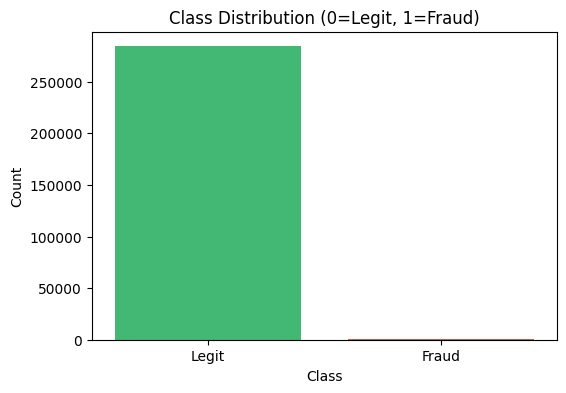

In [ ]:
df = pd.read_csv('creditcard.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nClass Distribution:")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean()*100:.4f}%")

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Class Distribution (0=Legit, 1=Fraud)')
plt.xticks([0,1], ['Legit', 'Fraud'])
plt.ylabel('Count')
plt.show()

In [ ]:

scaler = StandardScaler()

df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_Scaled'] = scaler.fit_transform(df[['Time']])


df = df.drop(['Amount', 'Time'], axis=1)


X = df.drop('Class', axis=1)
y = df['Class']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nFraud cases in training: {y_train.sum()}")
print(f"Fraud cases in test: {y_test.sum()}")


print("\nApplying SMOTE...")
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After SMOTE - Training set size: {X_train_sm.shape}")
print(f"Fraud cases after SMOTE: {y_train_sm.sum()}")
print(" Data preprocessing complete")

Training set size: (227845, 30)
Test set size: (56962, 30)

Fraud cases in training: 394
Fraud cases in test: 98

Applying SMOTE...
After SMOTE - Training set size: (454902, 30)
Fraud cases after SMOTE: 227451
 Data preprocessing complete


In [ ]:
print("Training XGBoost model...")

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=1,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_sm, y_train_sm)

print(" Model trained ")

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]


print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

print(f" ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

Training XGBoost model...
 Model trained 

 Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.35      0.87      0.49        98

    accuracy                           1.00     56962
   macro avg       0.67      0.93      0.75     56962
weighted avg       1.00      1.00      1.00     56962

 ROC-AUC Score: 0.9760


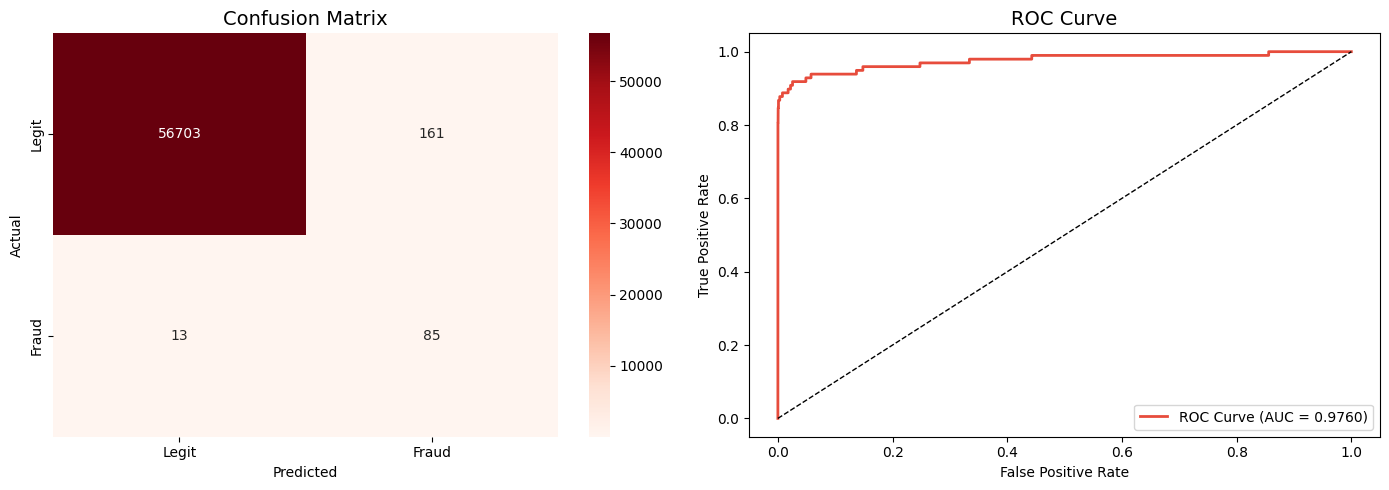

 Visualizations complete!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')


fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()
print(" Visualizations complete!")

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-8)
best_threshold_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_threshold_idx]

print(f"Best threshold: {best_threshold:.4f}")

y_pred_tuned = (y_pred_proba >= best_threshold).astype(int)

print("\n Classification Report AFTER threshold tuning:")
print(classification_report(y_test, y_pred_tuned, target_names=['Legit', 'Fraud']))

print(" before vs after:")
print(f"Fraud Recall:    {0.87:.2f}  →  {y_pred_tuned[y_test==1].mean():.2f}")
print(f"Fraud Precision: {0.35:.2f}  →  {(y_pred_tuned[y_test==1].sum() / y_pred_tuned.sum()):.2f}")

Best threshold: 0.9839

 Classification Report AFTER threshold tuning:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.92      0.81      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962

 before vs after:
Fraud Recall:    0.87  →  0.81
Fraud Precision: 0.35  →  0.92


Generating SHAP explanations...


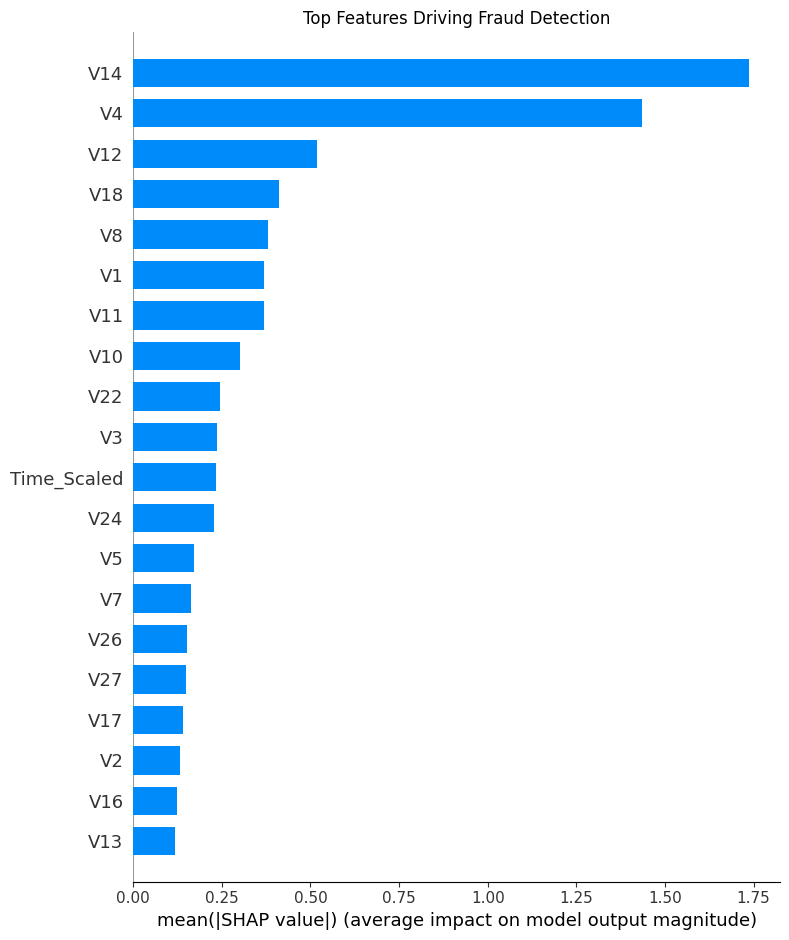

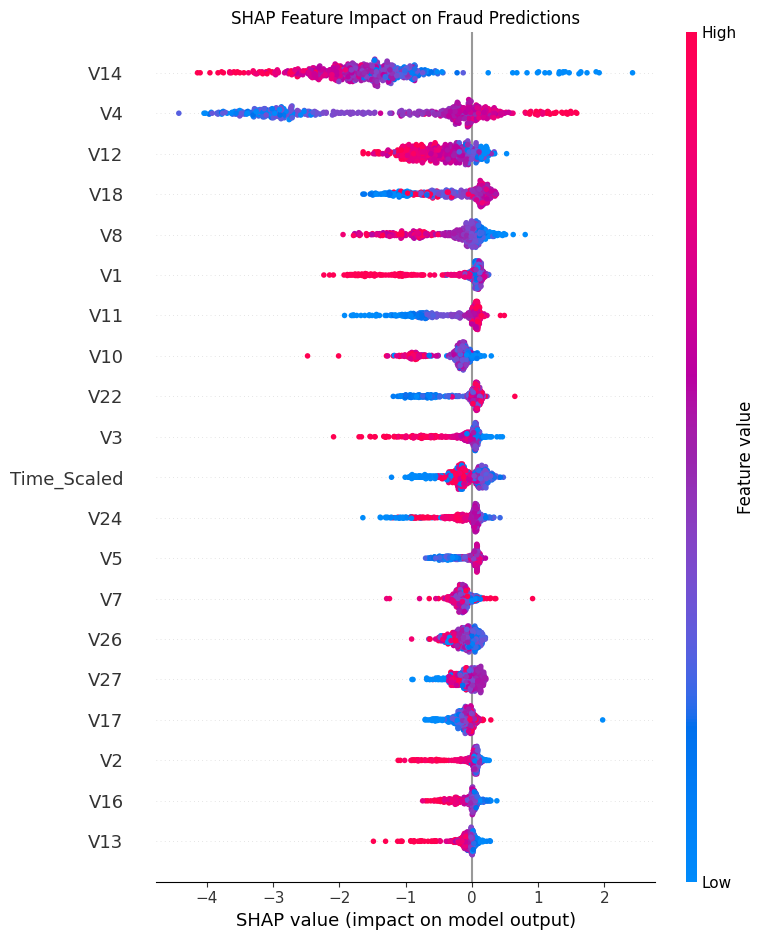

 SHAP complete!


In [ ]:
print("Generating SHAP explanations...")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:500])

plt.figure()
shap.summary_plot(shap_values, X_test[:500], plot_type="bar", show=False)
plt.title("Top Features Driving Fraud Detection")
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(shap_values, X_test[:500], show=False)
plt.title("SHAP Feature Impact on Fraud Predictions")
plt.tight_layout()
plt.show()

print(" SHAP complete!")

In [ ]:
import joblib
import json

joblib.dump(model, 'fraud_model.pkl')

joblib.dump(scaler, 'scaler.pkl')

with open('threshold.json', 'w') as f:
    json.dump({'threshold': float(best_threshold)}, f)

print(f" Model saved as fraud_model.pkl")
print(f" Scaler saved as scaler.pkl")
print(f" Threshold saved as threshold.json")
print(f"\n Best threshold: {best_threshold:.4f}")

 Model saved as fraud_model.pkl
 Scaler saved as scaler.pkl
 Threshold saved as threshold.json

 Best threshold: 0.9839


In [ ]:
from google.colab import files

files.download('fraud_model.pkl')
files.download('scaler.pkl')
files.download('threshold.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>